In [26]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv("wine.csv")

# Display first 5 rows
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
# Dataset structure
df.shape

(178, 14)

In [4]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
# Statistical summary
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
# Check missing values
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

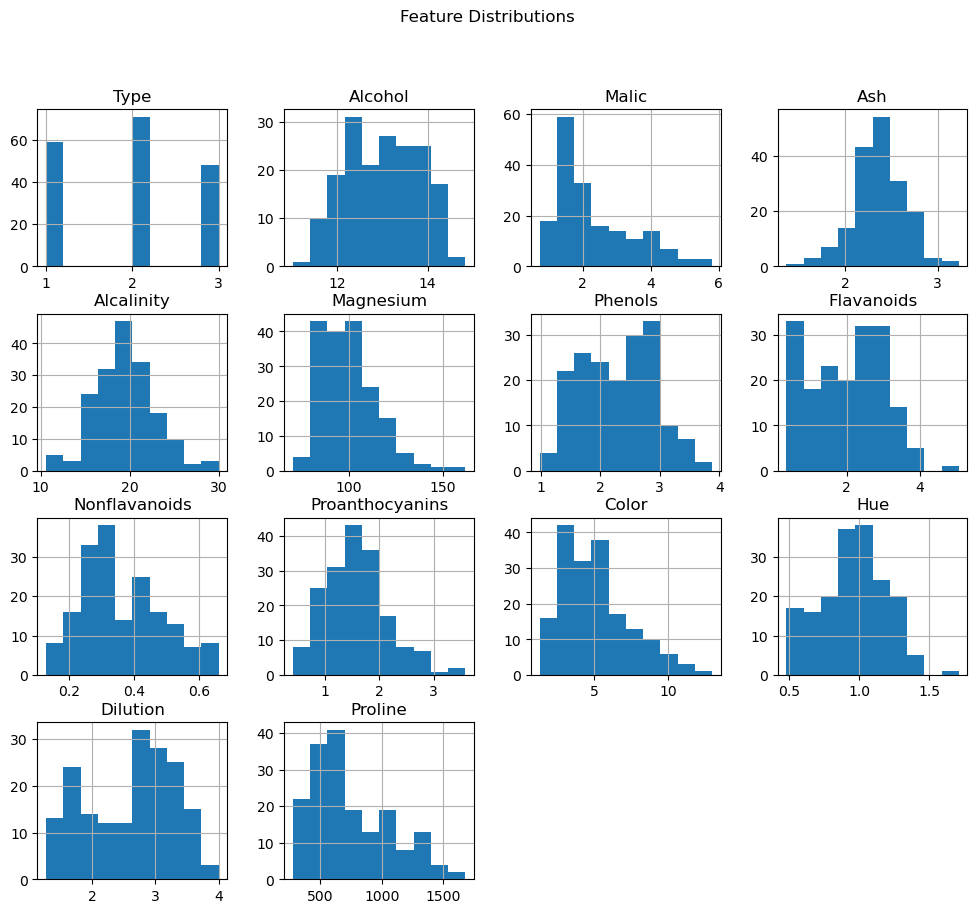

In [7]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

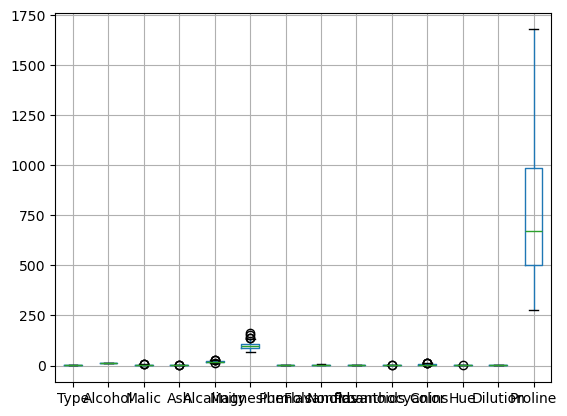

In [11]:
df.boxplot()
plt.show()

In [12]:
#### outlier capping

def outlier_capping(df,column):

    Q1= df[column].quantile(0.25)

    Q3= df[column].quantile(0.75)

    IQR= Q3-Q1

    lower_extreme= Q1-1.5*IQR

    upper_extreme= Q3+ 1.5*IQR

    df[column]= df[column].apply(lambda x:lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)

for col in df.select_dtypes(include=['int','float']).columns:

    outlier_capping(df,col)

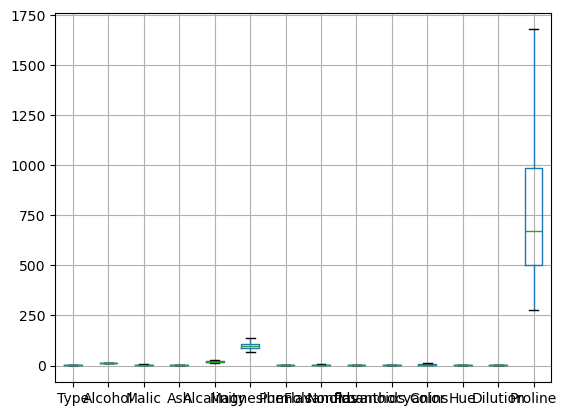

In [13]:
df.boxplot()
plt.show()

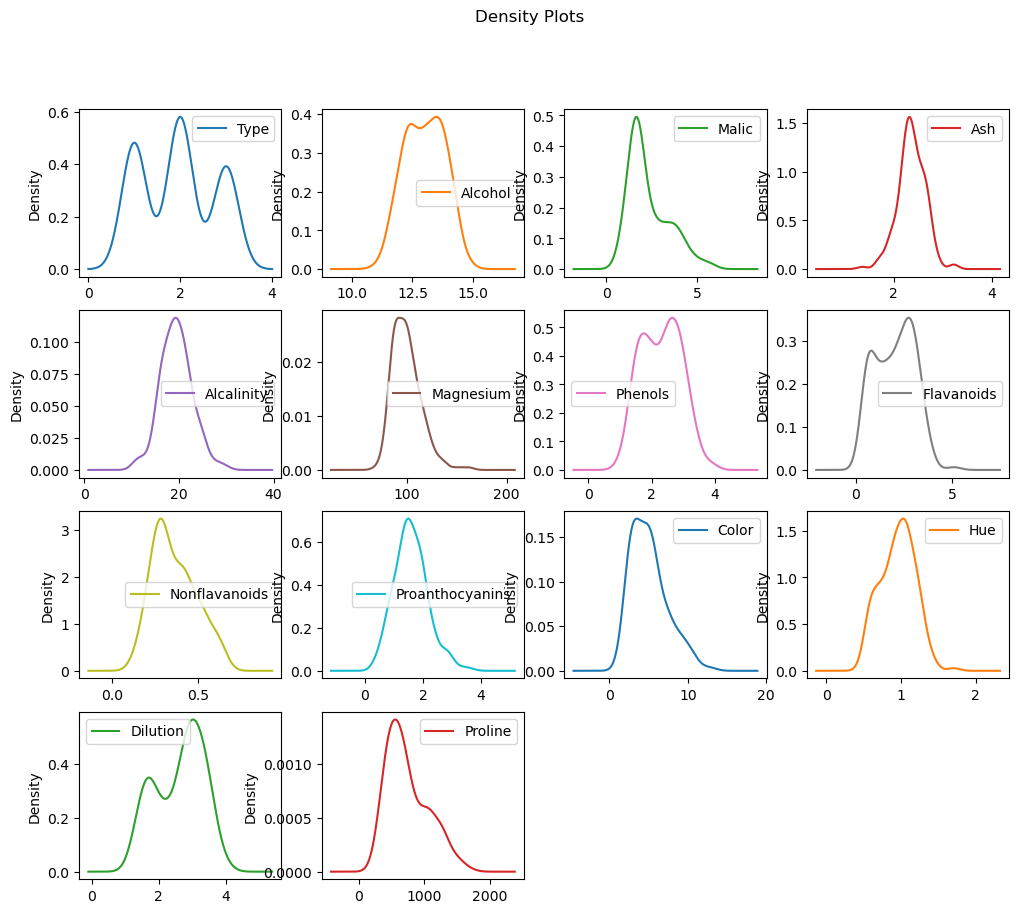

In [9]:
df.plot(kind='density', subplots=True, layout=(4,4), figsize=(12,10), sharex=False)
plt.suptitle("Density Plots")
plt.show()

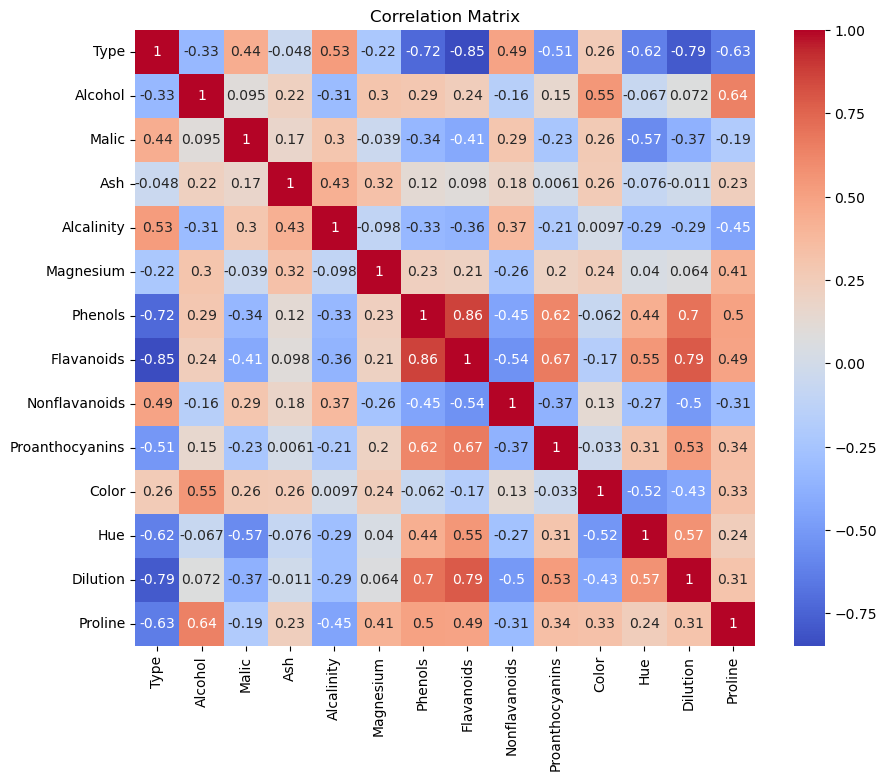

In [14]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# FIXED: Safe feature selection
if 'target' in df.columns:
    X = df.drop('target', axis=1)
elif 'class' in df.columns:
    X = df.drop('class', axis=1)
elif 'Type' in df.columns:
    X = df.drop('Type', axis=1)
else:
    X = df.copy()

# Standardization (mean = 0, std = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

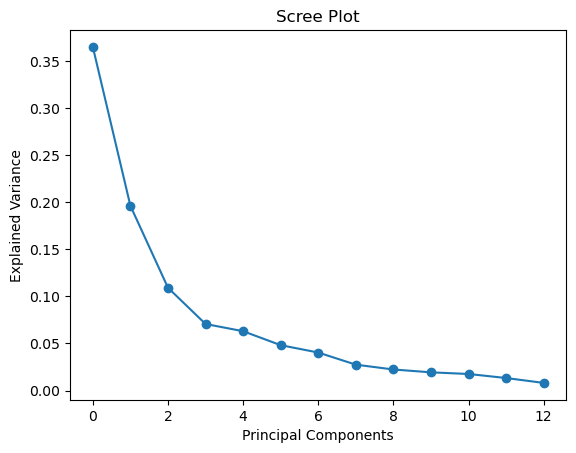

In [21]:
import matplotlib.pyplot as plt

plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.show()

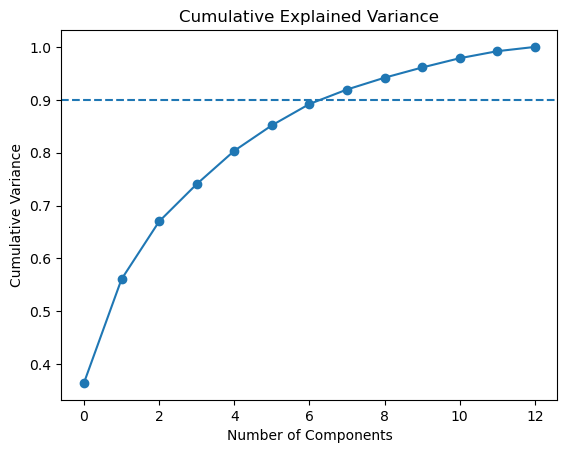

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Define and fit PCA FIRST
pca = PCA()
pca.fit(X_scaled)

# Now this will work
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumulative_variance, marker='o')
plt.axhline(y=0.9, linestyle='--')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Step 1: Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 3: Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
print(pca_df.head())

        PC1       PC2
0  3.358147  1.520222
1  2.229215 -0.333261
2  2.540057  1.036953
3  3.781124  2.782566
4  1.016872  0.955225


In [27]:
from sklearn.cluster import KMeans

# Apply K-Means (choose k=3 for wine dataset)
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit and predict
labels_original = kmeans.fit_predict(X_scaled)

print("Cluster Labels:\n", labels_original[:10])

Cluster Labels:
 [2 2 2 2 2 2 2 2 2 2]


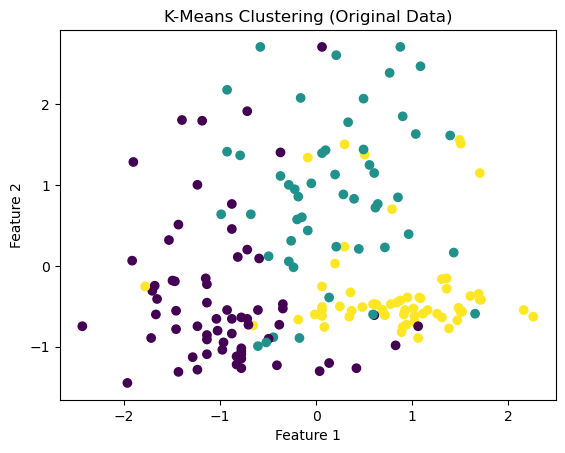

In [28]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_original)
plt.title("K-Means Clustering (Original Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [29]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(X_scaled, labels_original)
db_score = davies_bouldin_score(X_scaled, labels_original)

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Score:", db_score)

Silhouette Score: 0.2854626783251893
Davies-Bouldin Score: 1.3816062413276704


In [30]:
from sklearn.cluster import KMeans

# Apply K-Means on PCA-transformed data
kmeans_pca = KMeans(n_clusters=3, random_state=42)

labels_pca = kmeans_pca.fit_predict(X_pca)

print("Cluster Labels (PCA):\n", labels_pca[:10])

Cluster Labels (PCA):
 [2 2 2 2 2 2 2 2 2 2]


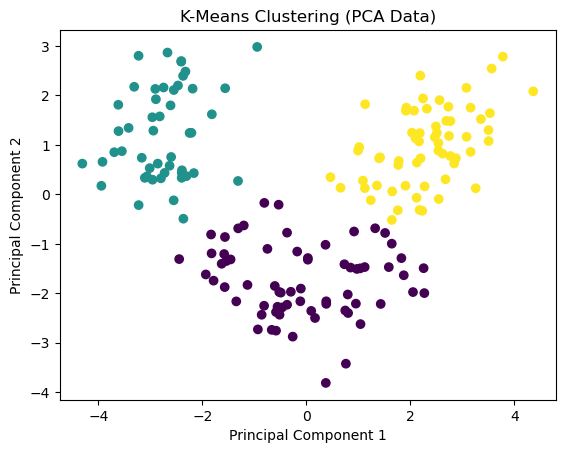

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca)
plt.title("K-Means Clustering (PCA Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [32]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score_pca = silhouette_score(X_pca, labels_pca)
db_score_pca = davies_bouldin_score(X_pca, labels_pca)

print("Silhouette Score (PCA):", sil_score_pca)
print("Davies-Bouldin Score (PCA):", db_score_pca)

Silhouette Score (PCA): 0.5613222019327238
Davies-Bouldin Score (PCA): 0.5983440957250454
